<a href="https://colab.research.google.com/github/Mohammadjar05/Project/blob/main/project1_Movie_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!


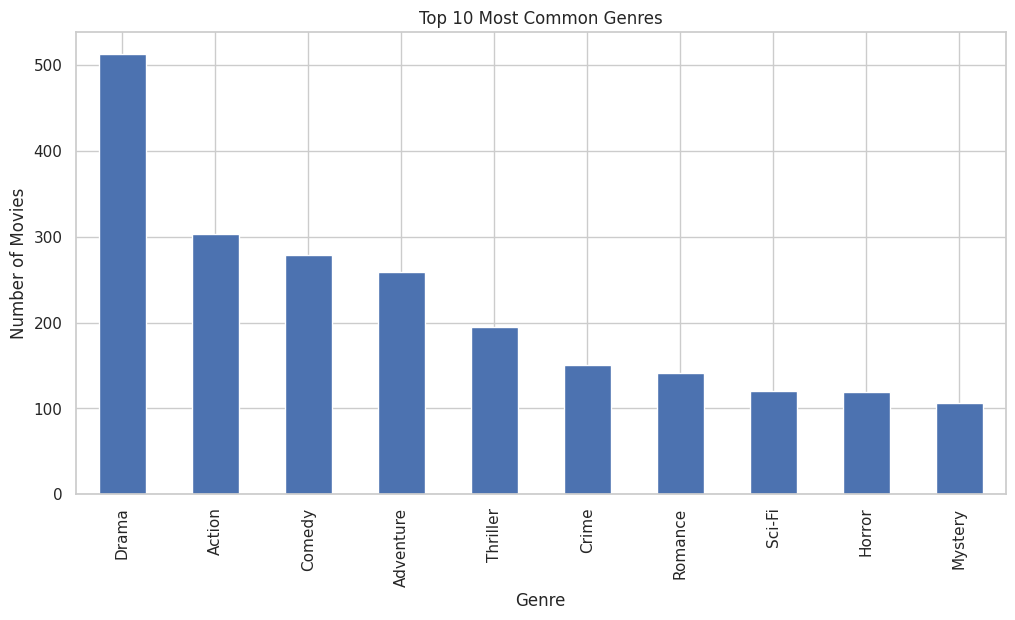

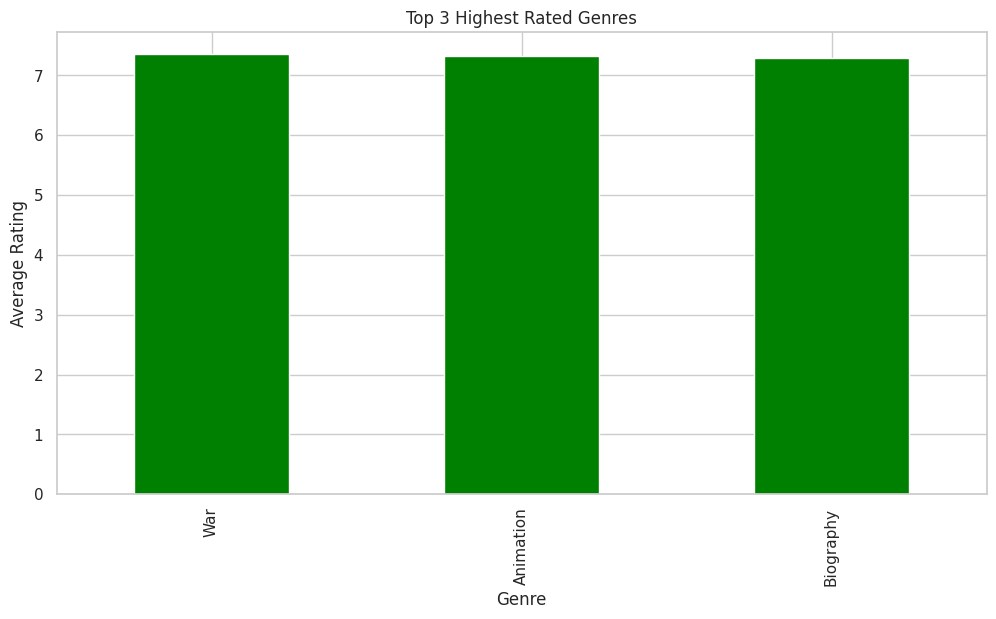

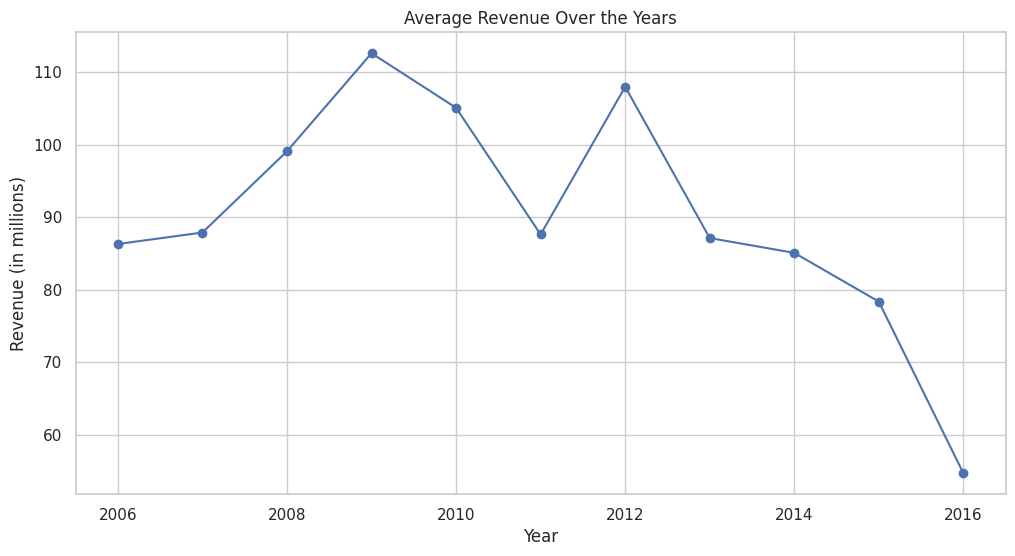

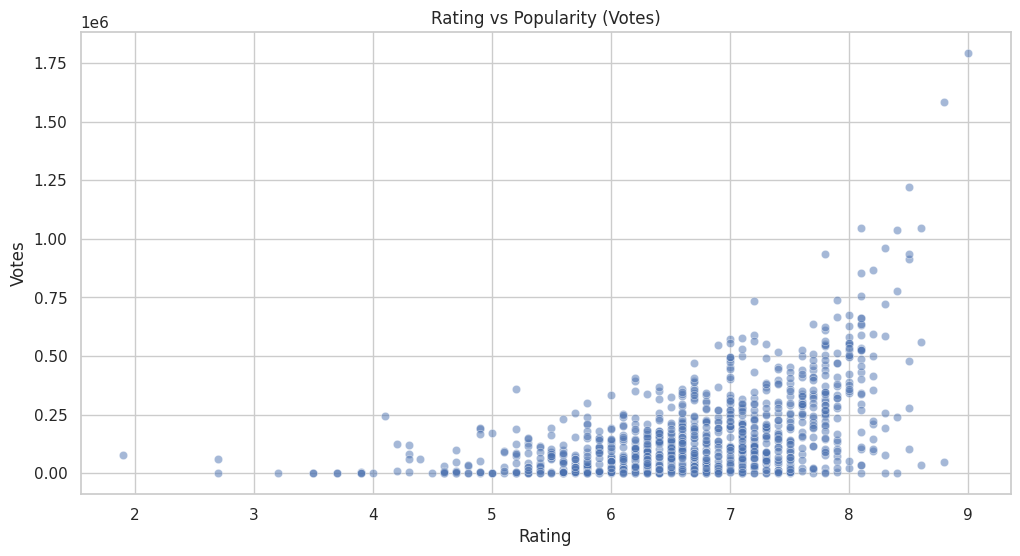

Correlation between Rating and Votes:
           Rating     Votes
Rating  1.000000  0.511537
Votes   0.511537  1.000000

Top 10 Movies by Revenue:
                                          Title  Revenue (Millions)
50   Star Wars: Episode VII - The Force Awakens              936.63
87                                       Avatar              760.51
85                               Jurassic World              652.18
76                                 The Avengers              623.28
54                              The Dark Knight              533.32
12                                    Rogue One              532.17
119                                Finding Dory              486.29
94                      Avengers: Age of Ultron              458.99
124                       The Dark Knight Rises              448.13
578             The Hunger Games: Catching Fire              424.65

--- Insights and Recommendations ---
1. Most frequent genres are Action, Drama, and Comedy.
2. Documenta

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('IMDB-Movie-Data.csv')
print("Dataset loaded successfully!")
df.head()

df['Genre'] = df['Genre'].fillna('')
df_genres = df.assign(Genre=df['Genre'].str.split(',')).explode('Genre')
df_genres['Genre'] = df_genres['Genre'].str.strip()

top_genres = df_genres['Genre'].value_counts().head(10)
top_genres.plot(kind='bar', title='Top 10 Most Common Genres')
plt.ylabel('Number of Movies')
plt.show()

avg_rating_by_genre = df_genres.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(3)
avg_rating_by_genre.plot(kind='bar', color='green', title='Top 3 Highest Rated Genres')
plt.ylabel('Average Rating')
plt.show()

df['Revenue (Millions)'] = pd.to_numeric(df['Revenue (Millions)'], errors='coerce')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

revenue_by_year = df.groupby('Year')['Revenue (Millions)'].mean().dropna()
revenue_by_year.plot(marker='o', title='Average Revenue Over the Years')
plt.ylabel('Revenue (in millions)')
plt.show()

df[['Rating', 'Votes']] = df[['Rating', 'Votes']].apply(pd.to_numeric, errors='coerce')

sns.scatterplot(data=df, x='Rating', y='Votes', alpha=0.5)
plt.title('Rating vs Popularity (Votes)')
plt.xlabel('Rating')
plt.ylabel('Votes')
plt.show()
correlation = df[['Rating', 'Votes']].corr()
print("Correlation between Rating and Votes:\n", correlation)
top_revenue = df.sort_values(by='Revenue (Millions)', ascending=False)[['Title', 'Revenue (Millions)']].dropna().head(10)
print("\nTop 10 Movies by Revenue:")
print(top_revenue)
print("\n--- Insights and Recommendations ---")
print("1. Most frequent genres are Action, Drama, and Comedy.")
print("2. Documentaries and Biographies tend to have the highest average ratings.")
print("3. Average revenue has fluctuated over the years with notable peaks.")
print("4. There's a moderate positive correlation between Ratings and Votes, indicating popular movies often receive better ratings.")
print("5. Consider focusing on high-rating genres like Biography and History for quality content.")